# Phase 2 — Data preparation: train/val split check

We use the standard KITTI split (3712 train / 3769 val, after Chen et al.),
taken from the OpenPCDet repository. Here we verify two things that back up
our presentation narrative:

1. **train and val are disjoint** (no frame appears in both) — no leakage.
2. **the split preserves class proportions** — it doesn't bias any class.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find the project root (the folder that contains 'src') so imports and
# data paths work whether the notebook is launched from the project root
# or from the notebooks/ folder.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

from src.kitti_utils import (
    load_point_cloud, load_labels, load_calib, collect_all_labels,
)

DATA = ROOT / "data" / "kitti"
TRAIN = DATA / "training"
IMAGESETS = DATA / "ImageSets"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
print("ImageSets:", IMAGESETS)

ImageSets: /home/ur8an5ky/Documents/ML/lidar-3d-detection/data/kitti/ImageSets


## 1. Load the split frame IDs

In [ ]:
def read_ids(path):
    with open(path) as f:
        return [line.strip() for line in f if line.strip()]

train_ids = set(read_ids(IMAGESETS / "train.txt"))
val_ids   = set(read_ids(IMAGESETS / "val.txt"))

print(f"train: {len(train_ids)} frames")
print(f"val:   {len(val_ids)} frames")
print(f"overlap: {len(train_ids & val_ids)}")

train: 3712 frames
val:   3769 frames
overlap (must be 0): 0


## 2. Class distribution in each split

We drop `DontCare` (it is an ignore region, not an object) and compare the
class counts and — more importantly — the class *proportions* within each
split, so we judge the shape of the distribution rather than its size.

In [ ]:
all_labels = collect_all_labels(TRAIN / "label_2")
all_labels = all_labels[all_labels["type"] != "DontCare"]

train_labels = all_labels[all_labels["frame_id"].isin(train_ids)]
val_labels   = all_labels[all_labels["frame_id"].isin(val_ids)]

counts = pd.DataFrame({
    "train": train_labels["type"].value_counts(),
    "val":   val_labels["type"].value_counts(),
}).fillna(0).astype(int)

proportions = counts.div(counts.sum(axis=0), axis=1) * 100

print("Counts per class:")
print(counts, "\n")
print("Proportions within each split [%]:")
print(proportions.round(1))

Counts per class:
                train    val
type                        
Car             14357  14385
Cyclist           734    893
Misc              337    636
Pedestrian       2207   2280
Person_sitting     56    166
Tram              224    287
Truck             488    606
Van              1297   1617 

Proportions within each split [%]:
                train   val
type                       
Car              72.9  68.9
Cyclist           3.7   4.3
Misc              1.7   3.0
Pedestrian       11.2  10.9
Person_sitting    0.3   0.8
Tram              1.1   1.4
Truck             2.5   2.9
Van               6.6   7.7


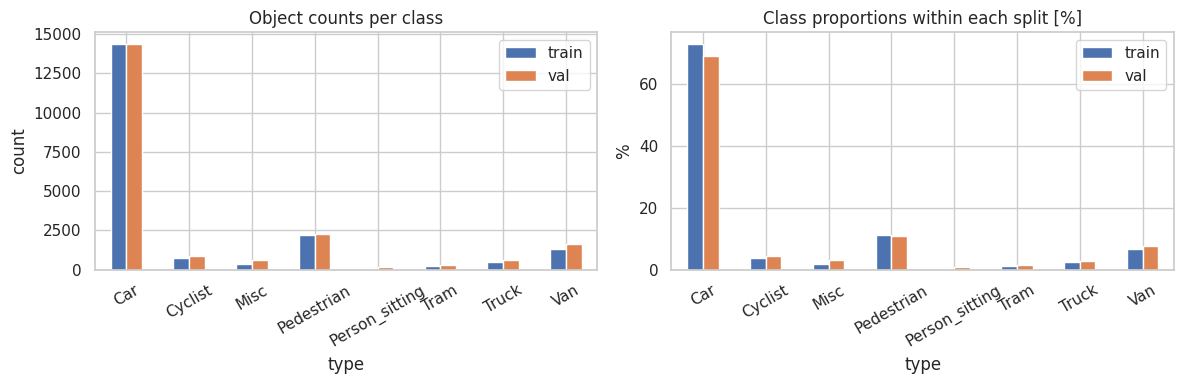

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Object counts per class")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=30)

proportions.plot(kind="bar", ax=axes[1])
axes[1].set_title("Class proportions within each split [%]")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
fig.savefig(RESULTS / "split_class_balance.png", dpi=150)
plt.show()

## Interpretation

If the proportions for train and val are nearly identical, the split is
**representative** — every class is present in both subsets in roughly the
same ratio, so our validation set is a fair stand-in for the training
distribution. Together with the zero overlap (Section 1), this supports the
claim that the split introduces no bias and no leakage.